In [1]:
# Cell 1 - Import libraries and load cleaned dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset
df = pd.read_csv('../data/cleaned/nibss_banking_cleaned.csv')

print("Cleaned dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df[['transaction_id', 'customer_id', 'amount', 'channel', 'bank', 'is_fraud', 'fraud_technique']].head())

Cleaned dataset loaded successfully
Shape: (20000, 42)

First 5 rows:
     transaction_id    customer_id     amount channel       bank  is_fraud  \
0  TXN_F08A86FFD87C  CUST_0002AED1   32266.83  Mobile   Sterling         0   
1  TXN_C2D08134EC83  CUST_0002AED1   72530.49     Web        UBA         0   
2  TXN_B9499111901D  CUST_0002AED1  168152.87  Mobile       Wema         0   
3  TXN_48DB1D526A3B  CUST_0002AED1   16439.93  Mobile       FCMB         0   
4  TXN_56DB1E28B758  CUST_0002AED1    9922.68     POS  FirstBank         0   

  fraud_technique  
0      Legitimate  
1      Legitimate  
2      Legitimate  
3      Legitimate  
4      Legitimate  


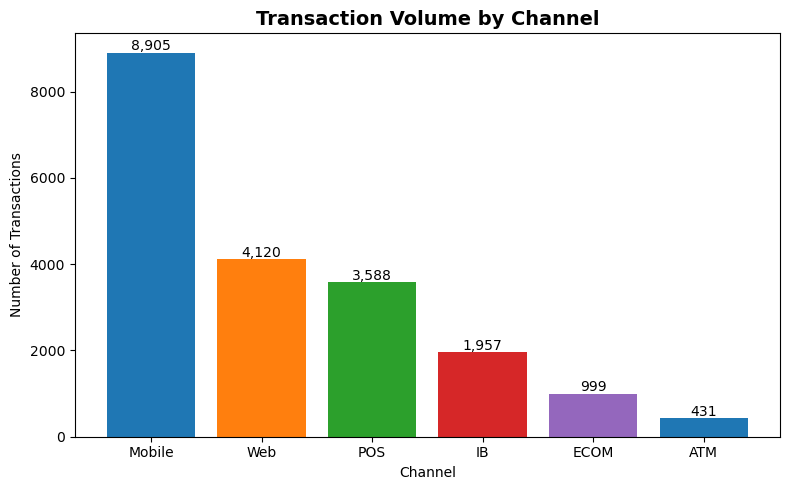


Channel breakdown:
channel
Mobile    8905
Web       4120
POS       3588
IB        1957
ECOM       999
ATM        431
Name: count, dtype: int64


In [2]:
# Cell 2 - Transaction volume by channel
channel_counts = df['channel'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(channel_counts.index, channel_counts.values, 
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Transaction Volume by Channel', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
for bar, val in zip(bars, channel_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../images/01_transactions_by_channel.png', dpi=150)
plt.show()
print(f"\nChannel breakdown:\n{channel_counts}")

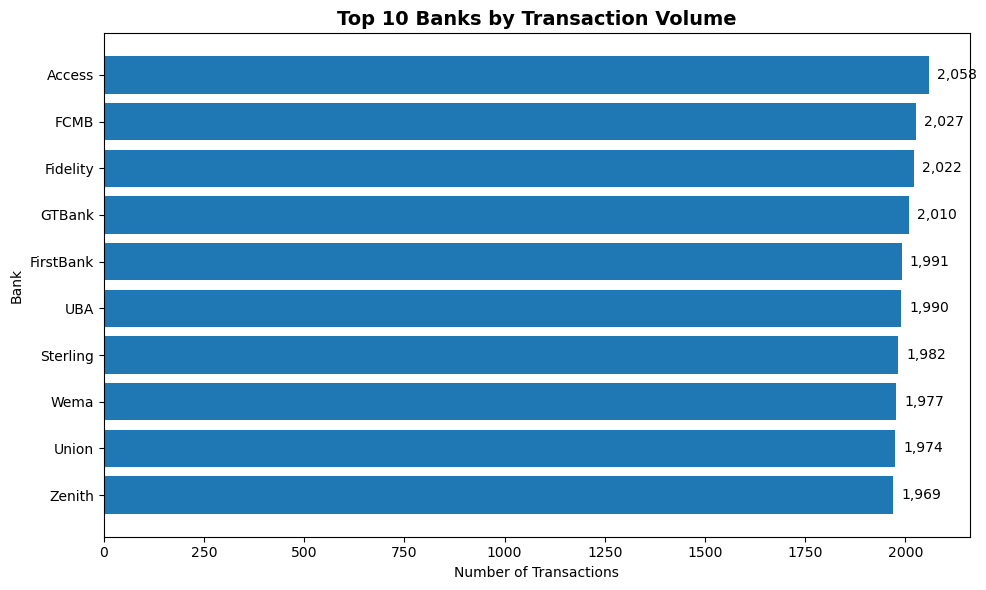


Top 10 banks:
bank
Access       2058
FCMB         2027
Fidelity     2022
GTBank       2010
FirstBank    1991
UBA          1990
Sterling     1982
Wema         1977
Union        1974
Zenith       1969
Name: count, dtype: int64


In [3]:
# Cell 3 - Top 10 banks by transaction volume
bank_counts = df['bank'].value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(bank_counts.index[::-1], bank_counts.values[::-1], 
                color='#1f77b4')
plt.title('Top 10 Banks by Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Transactions')
plt.ylabel('Bank')
for bar, val in zip(bars, bank_counts.values[::-1]):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../images/02_top_banks_by_volume.png', dpi=150)
plt.show()
print(f"\nTop 10 banks:\n{bank_counts}")

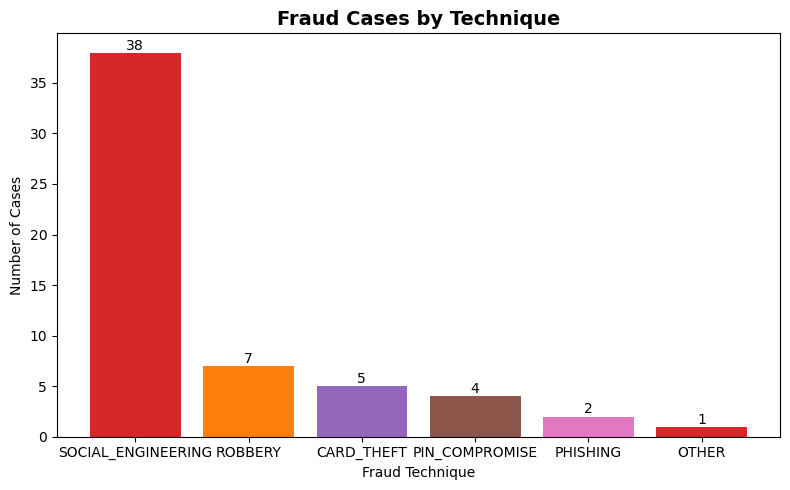


Fraud breakdown:
fraud_technique
SOCIAL_ENGINEERING    38
ROBBERY                7
CARD_THEFT             5
PIN_COMPROMISE         4
PHISHING               2
OTHER                  1
Name: count, dtype: int64

Total fraud cases: 57
Fraud rate: 0.29%


In [4]:
# Cell 4 - Fraud technique breakdown
fraud_df = df[df['is_fraud'] == 1]
fraud_counts = fraud_df['fraud_technique'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(fraud_counts.index, fraud_counts.values,
               color=['#d62728', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2'])
plt.title('Fraud Cases by Technique', fontsize=14, fontweight='bold')
plt.xlabel('Fraud Technique')
plt.ylabel('Number of Cases')
for bar, val in zip(bars, fraud_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../images/03_fraud_by_technique.png', dpi=150)
plt.show()
print(f"\nFraud breakdown:\n{fraud_counts}")
print(f"\nTotal fraud cases: {len(fraud_df)}")
print(f"Fraud rate: {(len(fraud_df)/len(df)*100):.2f}%")

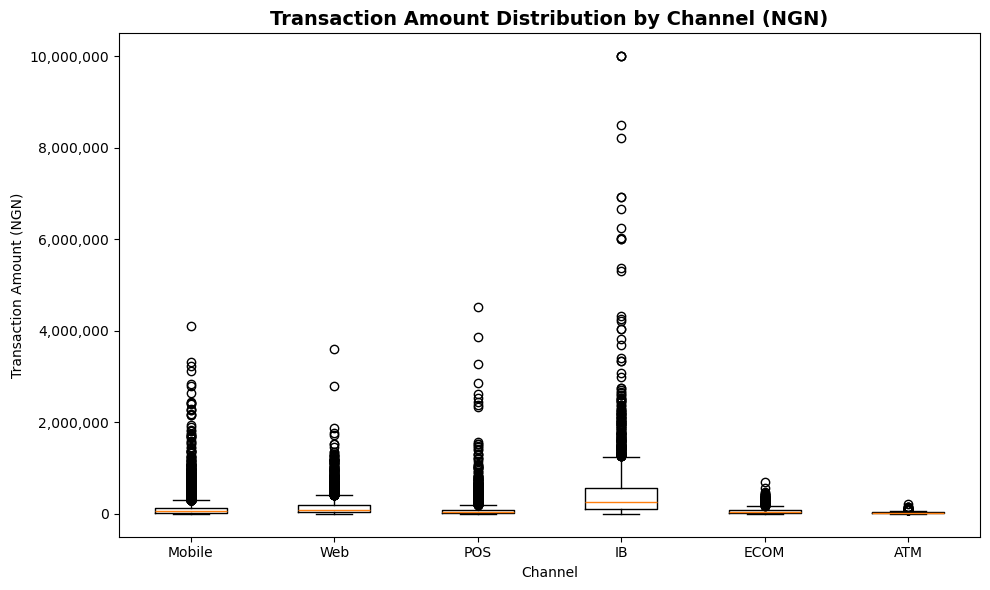


Amount summary by channel:
              mean      min          max
channel                                 
ATM       31234.33  3246.73    207239.73
ECOM      73295.80  2598.84    692117.04
IB       500644.58  3335.24  10000000.00
Mobile   120224.92   784.42   4114775.10
POS       93925.45   348.74   4523869.25
Web      159149.21  1563.97   3593736.00


In [5]:
# Cell 5 - Transaction amount distribution by channel
plt.figure(figsize=(10, 6))
channels = df['channel'].unique()
data_to_plot = [df[df['channel'] == ch]['amount'].values for ch in channels]

plt.boxplot(data_to_plot, labels=channels)
plt.title('Transaction Amount Distribution by Channel (NGN)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Transaction Amount (NGN)')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../images/04_amount_distribution_by_channel.png', dpi=150)
plt.show()

print("\nAmount summary by channel:")
print(df.groupby('channel')['amount'].agg(['mean', 'min', 'max']).round(2))

In [6]:
# Cell 6 - KPI Summary
print("=" * 50)
print("NIBSS BANKING OPERATIONS - KPI SUMMARY")
print("=" * 50)

total_txn = len(df)
total_amount = df['amount'].sum()
avg_amount = df['amount'].mean()
fraud_cases = df['is_fraud'].sum()
fraud_rate = (fraud_cases / total_txn) * 100
top_channel = df['channel'].value_counts().index[0]
top_bank = df['bank'].value_counts().index[0]
top_fraud = df[df['is_fraud']==1]['fraud_technique'].value_counts().index[0]

print(f"\nTotal Transactions Analysed : {total_txn:,}")
print(f"Total Transaction Value (NGN): {total_amount:,.2f}")
print(f"Average Transaction Amount   : {avg_amount:,.2f}")
print(f"Total Fraud Cases            : {fraud_cases}")
print(f"Fraud Rate                   : {fraud_rate:.2f}%")
print(f"Top Transaction Channel      : {top_channel}")
print(f"Top Bank by Volume           : {top_bank}")
print(f"Most Common Fraud Technique  : {top_fraud}")
print("\n" + "=" * 50)

NIBSS BANKING OPERATIONS - KPI SUMMARY

Total Transactions Analysed : 20,000
Total Transaction Value (NGN): 3,129,748,077.69
Average Transaction Amount   : 156,487.40
Total Fraud Cases            : 57
Fraud Rate                   : 0.29%
Top Transaction Channel      : Mobile
Top Bank by Volume           : Access
Most Common Fraud Technique  : SOCIAL_ENGINEERING

